# **Sentimen Analisis Review APK Play Store**

Selamat datang dalam Proyek Analisis Sentimen Ulasan Aplikasi Webtoon (LINE Webtoon) di Play Store!

Di era digital saat ini, ulasan pengguna memainkan peran penting dalam membentuk persepsi terhadap suatu aplikasi. Terutama Webtoon, sebagai salah satu platform komik digital terbesar di Indonesia, menerima ribuan ulasan dari pengguna setiap harinya. Melalui proyek ini, kita akan menjelajahi bagaimana pengguna merasakan pengalaman menggunakan aplikasi Webtoon, mulai dari kualitas cerita, kenyamanan membaca, hingga fitur-fitur dalam aplikasinya.

Analisis sentimen memungkinkan kita untuk secara otomatis mengidentifikasi apakah ulasan-ulasan tersebut bersifat positif, negatif, atau netral. Proyek ini bertujuan untuk memberikan wawasan mendalam mengenai persepsi dan kepuasan pengguna terhadap aplikasi Webtoon, yang nantinya bisa dimanfaatkan untuk pengambilan keputusan strategis, perbaikan fitur, dan peningkatan kualitas layanan aplikasi.

Dalam perjalanan ini, kita akan mempelajari berbagai konsep penting dalam analisis sentimen, seperti:

- Pra-pemrosesan teks ulasan,
- Ekstraksi fitur dari data teks,
- Dan penerapan model machine learning untuk klasifikasi sentimen.

Kita akan menggunakan bahasa pemrograman Python beserta pustaka populer seperti NLTK, scikit-learn, dan TensorFlow untuk membangun sistem analisis sentimen yang andal.

Proyek ini tidak hanya akan memperkaya pemahaman Anda tentang persepsi pengguna Webtoon, tetapi juga membekali Anda dengan keterampilan penting dalam pemrosesan bahasa alami dan machine learning.

# **Import Library**

In [47]:
import pandas as pd  # Pandas untuk manipulasi dan analisis data
import numpy as np  # NumPy untuk komputasi numerik
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, classification_report

import datetime as dt  # Manipulasi data waktu dan tanggal
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks
 
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

# Loading Dataset

In [2]:
# Membaca file CSV hasil scraping
app_reviews_df = pd.read_csv('reviews_aplikasi.csv')

# Menampilkan lima baris pertama dari DataFrame app_reviews_df
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,beabc610-0bc7-4046-bc00-d83c3d86c2db,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya menggunakan aplikasi ini sudah lama. Vitu...,5,550,3.6.2,2025-03-29 18:32:43,NaN,NaN,3.6.2
1,fb236561-5da0-4efa-9407-e52487abf420,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,hari sebelum nya masih bisa baca yg blm di bac...,3,5,3.6.4,2025-04-14 21:33:20,NaN,NaN,3.6.4
2,e15bc4cc-5796-42ee-8b86-813bf313dacd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Saya sudah menjadi penikmat Webtoon sejak 2016...,1,5,3.6.2,2025-04-16 11:13:48,NaN,NaN,3.6.2
3,28955196-2cea-4fad-9977-f0dab4a7e42f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tampilan berandanya(home) aneh.. kayak ga bera...,4,1100,3.6.0,2025-03-07 05:01:26,NaN,NaN,3.6.0
4,944f6d86-18f6-4445-8661-2a3d5f192846,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Untuk aplikasinya memang bagus, dan banyak fit...",5,2121,3.6.0,2025-03-05 15:00:52,NaN,NaN,3.6.0


In [3]:
# Menampilkan informasi tentang DataFrame app_reviews_df
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103500 entries, 0 to 103499
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              103500 non-null  object
 1   userName              103500 non-null  object
 2   userImage             103500 non-null  object
 3   content               103500 non-null  object
 4   score                 103500 non-null  int64 
 5   thumbsUpCount         103500 non-null  int64 
 6   reviewCreatedVersion  79975 non-null   object
 7   at                    103500 non-null  object
 8   replyContent          345 non-null     object
 9   repliedAt             345 non-null     object
 10  appVersion            79975 non-null   object
dtypes: int64(2), object(9)
memory usage: 8.7+ MB


In [4]:
app_reviews_df.shape

(103500, 11)

In [5]:
# Hapus kolom
clean_df = app_reviews_df.drop(columns=['replyContent', 'repliedAt', 'reviewCreatedVersion'])

# Cek DataFrame setelah kolom dihapus
print(f"Jumlah ulasan setelah kolom dihapus: {len(clean_df)}")
clean_df.head()

Jumlah ulasan setelah kolom dihapus: 103500


,reviewId,userName,userImage,content,score,thumbsUpCount,at,appVersion
0,beabc610-0bc7-4046-bc00-d83c3d86c2db,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya menggunakan aplikasi ini sudah lama. Vitu...,5,550,2025-03-29 18:32:43,3.6.2
1,fb236561-5da0-4efa-9407-e52487abf420,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,hari sebelum nya masih bisa baca yg blm di bac...,3,5,2025-04-14 21:33:20,3.6.4
2,e15bc4cc-5796-42ee-8b86-813bf313dacd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Saya sudah menjadi penikmat Webtoon sejak 2016...,1,5,2025-04-16 11:13:48,3.6.2
3,28955196-2cea-4fad-9977-f0dab4a7e42f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tampilan berandanya(home) aneh.. kayak ga bera...,4,1100,2025-03-07 05:01:26,3.6.0
4,944f6d86-18f6-4445-8661-2a3d5f192846,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Untuk aplikasinya memang bagus, dan banyak fit...",5,2121,2025-03-05 15:00:52,3.6.0


In [6]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103500 entries, 0 to 103499
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   reviewId       103500 non-null  object
 1   userName       103500 non-null  object
 2   userImage      103500 non-null  object
 3   content        103500 non-null  object
 4   score          103500 non-null  int64 
 5   thumbsUpCount  103500 non-null  int64 
 6   at             103500 non-null  object
 7   appVersion     79975 non-null   object
dtypes: int64(2), object(6)
memory usage: 6.3+ MB


In [7]:
# Menghapus baris duplikat dari DataFrame clean_df
clean_df = clean_df.drop_duplicates()
 
# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = clean_df.shape

print("Jumlah ulasan:", jumlah_ulasan_setelah_hapus_duplikat)
print("Jumlah kolom:", jumlah_kolom_setelah_hapus_duplikat)

Jumlah ulasan: 103500
Jumlah kolom: 8


In [8]:
clean_df.shape

(103500, 8)

In [9]:
clean_df.content.value_counts()

content
bagus           3186
keren           1377
mantap           936
good             926
bagus banget     702
                ... 
Sio                1
B. Aja             1
The best💜          1
I like 🤣           1
Love😘              1
Name: count, Length: 80073, dtype: int64

In [10]:
clean_df.score.value_counts()

score
5    73098
4    10771
1     9782
3     6209
2     3640
Name: count, dtype: int64

# Preprocessing

Berikut adalah beberapa fungsi yang digunakan untuk membersihkan dan memproses teks. Inilah penjelasan singkat tentang masing-masing fungsi:

1. `cleaningText(text)`: Fungsi ini digunakan untuk membersihkan teks dengan beberapa langkah, seperti menghapus mention, hashtag, RT (retweet), tautan (link), angka, dan tanda baca. Selain itu, itu juga menggantikan karakter newline dengan spasi dan menghilangkan spasi ekstra di awal dan akhir teks.

2. `casefoldingText(text)`: Fungsi ini mengonversi semua karakter dalam teks menjadi huruf kecil (lowercase), sehingga teks menjadi lebih seragam.

3. `tokenizingText(text)`: Fungsi ini digunakan untuk membagi teks menjadi daftar kata atau token. Ini berguna untuk mengurai teks menjadi komponen-komponen dasar.

4. `filteringText(text)`: Fungsi ini digunakan untuk menghapus kata-kata berhenti (stopwords) dalam teks. Anda telah memperbarui daftar kata-kata berhenti dengan beberapa kata tambahan.

5. `stemmingText(text)`: Fungsi ini menerapkan stemming pada teks, yaitu mengurangi kata-kata menjadi bentuk dasarnya. Anda menggunakan pustaka Sastrawi untuk melakukan stemming dalam bahasa Indonesia.

6. `toSentence(list_words)`: Fungsi ini digunakan untuk menggabungkan daftar kata-kata menjadi sebuah kalimat.

Anda dapat menggunakan fungsi-fungsi ini dalam proyek Anda untuk membersihkan, memproses, dan mempersiapkan teks sebelum melakukan analisis sentimen. Pastikan untuk memanggil fungsi-fungsi ini dengan benar sesuai dengan tahap pemrosesan teks yang Anda inginkan.

In [11]:
import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stopwords) dalam berbagai bahasa.

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [12]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka
 
    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text
 
def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text
 
def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text
 
def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text
 
def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
 
    # Memecah teks menjadi daftar kata
    words = text.split()
 
    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]
 
    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)
 
    return stemmed_text
 
def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [13]:
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "plisss": "tolong", "bgttt": "banget", "indo": "indonesia", "bgtt": "banget", "ad": "ada", "rv": "redvelvet", "plis": "tolong", "pls": "tolong", "cr": "sumber", "cod": "bayar ditempat", "adlh": "adalah", "afaik": "as far as i know", "ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang", "ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan", "beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana", "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur", "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar", "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor", "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat", "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan", "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana", "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya", "emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile", "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja", "gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi", "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol", "githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda", "gpny": "tidak punya", "gr": "gede rasa", "gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo", "hankam": "pertahanan dan keamanan", "hehe": "he", "helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah", "humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja", "jadiin": "jadi", "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar", "jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan", "kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu", "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya", "kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau", "kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau", "klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya", "komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim", "kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan", "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara", "latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan", "lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu", "lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo", "mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali", "mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol", "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa", "mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional", "muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana", "napza": "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri", "ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan", "ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis", "ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara", "ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing", "ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk", "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu", "ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan", "pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri", "pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah", "perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi", "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus", "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit", "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "tdi": "tadi", "te2p": "tetap", "tekor": "rugi", "telkom": "telekomunikasi", "telp": "telepon", "temen2": "teman-teman", "tengok": "menjenguk", "terbitin": "terbitkan", "tgl": "tanggal", "thanks": "terima kasih", "thd": "terhadap", "thx": "terima kasih", "tipi": "TV", "tkg": "tukang", "tll": "terlalu", "tlpn": "telepon", "tman": "teman", "tmbh": "tambah", "tmn2": "teman-teman", "tmph": "tumpah", "tnda": "tanda", "tnh": "tanah", "togel": "toto gelap", "tp": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba", "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras", "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual", "tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

Kamus slang atau daftar kata-kata slang yang Anda berikan adalah kumpulan kata-kata slang bahasa Indonesia beserta terjemahan atau artinya dalam bahasa formal. Fungsi dari kamus slang seperti ini adalah:

1. **Mengartikan Slang:** Kamus slang membantu orang yang mungkin tidak familiar dengan bahasa slang atau ekspresi yang digunakan di kalangan tertentu untuk memahami makna kata-kata tersebut.

2. **Komunikasi Informal:** Slang sering digunakan dalam percakapan informal atau di media sosial. Kamus slang membantu orang untuk berkomunikasi dengan gaya yang lebih santai dan sesuai dengan konteksnya.

3. **Pemahaman Budaya Pop:** Slang sering kali terkait dengan budaya pop dan dapat mencerminkan tren dan perubahan dalam bahasa. Kamus slang memungkinkan orang untuk mengikuti dan memahami bahasa dalam konteks budaya ini.

4. **Penggunaan Sastra dan Penulisan:** Penulis atau pembicara mungkin ingin menggunakan slang dalam tulisannya untuk menciptakan efek tertentu atau mengekspresikan karakter atau setting yang lebih realistis. Kamus slang dapat membantu mereka memilih kata-kata dengan tepat.

5. **Hiburan dan Curiositas:** Beberapa orang mungkin tertarik untuk mempelajari bahasa slang hanya untuk hiburan atau karena rasa ingin tahu terhadap variasi bahasa dan ungkapan dalam bahasa sehari-hari.

Ingatlah bahwa penggunaan slang harus disesuaikan dengan konteks dan audiens. Slang cenderung lebih cocok untuk percakapan santai dengan teman-teman atau di lingkungan yang informal. Dalam situasi formal, penggunaan bahasa formal lebih sesuai.

In [14]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,at,appVersion
0,beabc610-0bc7-4046-bc00-d83c3d86c2db,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya menggunakan aplikasi ini sudah lama. Vitu...,5,550,2025-03-29 18:32:43,3.6.2
1,fb236561-5da0-4efa-9407-e52487abf420,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,hari sebelum nya masih bisa baca yg blm di bac...,3,5,2025-04-14 21:33:20,3.6.4
2,e15bc4cc-5796-42ee-8b86-813bf313dacd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Saya sudah menjadi penikmat Webtoon sejak 2016...,1,5,2025-04-16 11:13:48,3.6.2
3,28955196-2cea-4fad-9977-f0dab4a7e42f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tampilan berandanya(home) aneh.. kayak ga bera...,4,1100,2025-03-07 05:01:26,3.6.0
4,944f6d86-18f6-4445-8661-2a3d5f192846,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Untuk aplikasinya memang bagus, dan banyak fit...",5,2121,2025-03-05 15:00:52,3.6.0
...,...,...,...,...,...,...,...,...
103495,0bcdd865-d4f2-4ab9-bae2-789becd6fcc7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"I'm sorry, but why now I can't top up coins on...",4,0,2020-10-15 01:06:58,2.5.8
103496,69950b9e-5990-4caa-a1a8-3e9daf19d6d9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Kanvasnya tambah banyak karena Ciayo Comics di...,5,0,2020-09-25 13:26:21,2.5.8
103497,921c332a-4f92-4257-b7e3-ad5ddcfa049b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Wah gila sih keren + bagus recomendasi aku Rom...,5,0,2020-10-03 17:35:37,2.5.8
103498,b12ac2a1-7bd2-4237-8ca6-6e4caa287d3e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,KOIN ILANGGGGGG! PLIS BRING MY COIN BACK!,1,0,2020-10-02 03:57:56,2.5.8


In [15]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [16]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,at,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,beabc610-0bc7-4046-bc00-d83c3d86c2db,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya menggunakan aplikasi ini sudah lama. Vitu...,5,550,2025-03-29 18:32:43,3.6.2,saya menggunakan aplikasi ini sudah lama Vitur...,saya menggunakan aplikasi ini sudah lama vitur...,saya menggunakan aplikasi ini sudah lama vitur...,"[saya, menggunakan, aplikasi, ini, sudah, lama...","[aplikasi, vitur², aplikasi, oke, gambargambar...",aplikasi vitur² aplikasi oke gambargambarnya b...
1,fb236561-5da0-4efa-9407-e52487abf420,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,hari sebelum nya masih bisa baca yg blm di bac...,3,5,2025-04-14 21:33:20,3.6.4,hari sebelum nya masih bisa baca yg blm di bac...,hari sebelum nya masih bisa baca yg blm di bac...,hari sebelum nya masih bisa baca yang belum di...,"[hari, sebelum, nya, masih, bisa, baca, yang, ...","[baca, baca, tibatiba, list, baca, hilang, sih...",baca baca tibatiba list baca hilang sihh susah...
2,e15bc4cc-5796-42ee-8b86-813bf313dacd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Saya sudah menjadi penikmat Webtoon sejak 2016...,1,5,2025-04-16 11:13:48,3.6.2,Saya sudah menjadi penikmat Webtoon sejak dan...,saya sudah menjadi penikmat webtoon sejak dan...,saya sudah menjadi penikmat webtoon sejak dan ...,"[saya, sudah, menjadi, penikmat, webtoon, seja...","[penikmat, webtoon, sejujurnya, menyukai, vers...",penikmat webtoon sejujurnya menyukai versi web...
3,28955196-2cea-4fad-9977-f0dab4a7e42f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tampilan berandanya(home) aneh.. kayak ga bera...,4,1100,2025-03-07 05:01:26,3.6.0,Tampilan berandanyahome aneh kayak ga berasa k...,tampilan berandanyahome aneh kayak ga berasa k...,tampilan berandanyahome aneh kayak ga berasa k...,"[tampilan, berandanyahome, aneh, kayak, ga, be...","[tampilan, berandanyahome, aneh, kayak, berasa...",tampilan berandanyahome aneh kayak berasa kaya...
4,944f6d86-18f6-4445-8661-2a3d5f192846,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Untuk aplikasinya memang bagus, dan banyak fit...",5,2121,2025-03-05 15:00:52,3.6.0,Untuk aplikasinya memang bagus dan banyak fitu...,untuk aplikasinya memang bagus dan banyak fitu...,untuk aplikasinya memang bagus dan banyak fitu...,"[untuk, aplikasinya, memang, bagus, dan, banya...","[aplikasinya, bagus, fitur, membantu, manhwa, ...",aplikasinya bagus fitur membantu manhwa dewasa...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103495,0bcdd865-d4f2-4ab9-bae2-789becd6fcc7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"I'm sorry, but why now I can't top up coins on...",4,0,2020-10-15 01:06:58,2.5.8,Im sorry but why now I cant top up coins on th...,im sorry but why now i cant top up coins on th...,im maaf but why now i cant top up coins on the...,"[im, maaf, but, why, now, i, cant, top, up, co...","[im, maaf, cant, top, coins, webtoon, even, th...",im maaf cant top coins webtoon even though pro...
103496,69950b9e-5990-4caa-a1a8-3e9daf19d6d9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Kanvasnya tambah banyak karena Ciayo Comics di...,5,0,2020-09-25 13:26:21,2.5.8,Kanvasnya tambah banyak karena Ciayo Comics di...,kanvasnya tambah banyak karena ciayo comics di...,kanvasnya tambah banyak karena ciayo comics di...,"[kanvasnya, tambah, banyak, karena, ciayo, com...","[kanvasnya, ciayo, comics, ditutupsoul, neko, ...",kanvasnya ciayo comics ditutupsoul neko pindah...
103497,921c332a-4f92-4257-b7e3-ad5ddcfa049b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Wah gila sih keren + bagus recomendasi aku Rom...,5,0,2020-10-03 17:35:37,2.5.8,Wah gila sih keren bagus recomendasi aku Roma...,wah gila sih keren bagus recomendasi aku roma...,wah gila sih keren bagus recomendasi aku roma

# Pelabelan

In [17]:
print(clean_df.columns)

Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'at', 'appVersion', 'text_clean',
       'text_casefoldingText', 'text_slangwords', 'text_tokenizingText',
       'text_stopword', 'text_akhir'],
      dtype='object')


In [18]:
import csv
import requests
from io import StringIO

# Loads positive lexicon data from GitHub
# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Loads negative lexicon data from GitHub
# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya ke dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [19]:
# Fungsi untuk menentukan polaritas sentimen dari tweet
def sentiment_analysis_lexicon_indonesia(text, low_threshold, high_threshold):
    score = 0
    for word in text:
        if word in lexicon_positive:
            score += lexicon_positive[word]
        if word in lexicon_negative:
            score += lexicon_negative[word]

    if score > high_threshold:
        polarity = 'positive'
    elif score < low_threshold:
        polarity = 'negative'
    else:
        polarity = 'natural'

    return score, polarity

# Hitung threshold dari data
all_scores = [sentiment_analysis_lexicon_indonesia(text, 0, 0)[0] for text in clean_df['text_stopword']]
low_threshold = np.percentile(all_scores, 33)
high_threshold = np.percentile(all_scores, 66)

# Salin DataFrame agar tidak menimpa
new_df = clean_df.copy()

# Simpan hasil analisis ke kolom baru
new_df['lexicon_score'], new_df['lexicon_polarity'] = zip(*new_df['text_stopword'].apply(
    lambda x: sentiment_analysis_lexicon_indonesia(x, low_threshold, high_threshold)
))

# Melihat distribusi polaritas
print(new_df['lexicon_polarity'].value_counts())

# Simpan ke CSV
new_df.to_csv('hasil_sentimen_lexicon.csv', index=False)
print("Data berhasil disimpan ke 'hasil_sentimen_lexicon.csv'")

lexicon_polarity
natural     48037
positive    35045
negative    20418
Name: count, dtype: int64
Data berhasil disimpan ke 'hasil_sentimen_lexicon.csv'


In [20]:
# Melihat kolom hasil sentimen
new_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,at,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,lexicon_score,lexicon_polarity
0,beabc610-0bc7-4046-bc00-d83c3d86c2db,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya menggunakan aplikasi ini sudah lama. Vitu...,5,550,2025-03-29 18:32:43,3.6.2,saya menggunakan aplikasi ini sudah lama Vitur...,saya menggunakan aplikasi ini sudah lama vitur...,saya menggunakan aplikasi ini sudah lama vitur...,"[saya, menggunakan, aplikasi, ini, sudah, lama...","[aplikasi, vitur², aplikasi, oke, gambargambar...",aplikasi vitur² aplikasi oke gambargambarnya b...,4,positive
1,fb236561-5da0-4efa-9407-e52487abf420,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,hari sebelum nya masih bisa baca yg blm di bac...,3,5,2025-04-14 21:33:20,3.6.4,hari sebelum nya masih bisa baca yg blm di bac...,hari sebelum nya masih bisa baca yg blm di bac...,hari sebelum nya masih bisa baca yang belum di...,"[hari, sebelum, nya, masih, bisa, baca, yang, ...","[baca, baca, tibatiba, list, baca, hilang, sih...",baca baca tibatiba list baca hilang sihh susah...,0,natural
2,e15bc4cc-5796-42ee-8b86-813bf313dacd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Saya sudah menjadi penikmat Webtoon sejak 2016...,1,5,2025-04-16 11:13:48,3.6.2,Saya sudah menjadi penikmat Webtoon sejak dan...,saya sudah menjadi penikmat webtoon sejak dan...,saya sudah menjadi penikmat webtoon sejak dan ...,"[saya, sudah, menjadi, penikmat, webtoon, seja...","[penikmat, webtoon, sejujurnya, menyukai, vers...",penikmat webtoon sejujurnya menyukai versi web...,5,positive
3,28955196-2cea-4fad-9977-f0dab4a7e42f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tampilan berandanya(home) aneh.. kayak ga bera...,4,1100,2025-03-07 05:01:26,3.6.0,Tampilan berandanyahome aneh kayak ga berasa k...,tampilan berandanyahome aneh kayak ga berasa k...,tampilan berandanyahome aneh kayak ga berasa k...,"[tampilan, berandanyahome, aneh, kayak, ga, be...","[tampilan, berandanyahome, aneh, kayak, berasa...",tampilan berandanyahome aneh kayak berasa kaya...,-14,negative
4,944f6d86-18f6-4445-8661-2a3d5f192846,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Untuk aplikasinya memang bagus, dan banyak fit...",5,2121,2025-03-05 15:00:52,3.6.0,Untuk aplikasinya memang bagus dan banyak fitu...,untuk aplikasinya memang bagus dan banyak fitu...,untuk aplikasinya memang bagus dan banyak fitu...,"[untuk, aplikasinya, memang, bagus, dan, banya...","[aplikasinya, bagus, fitur, membantu, manhwa, ...",aplikasinya bagus fitur membantu manhwa dewasa...,-7,negative


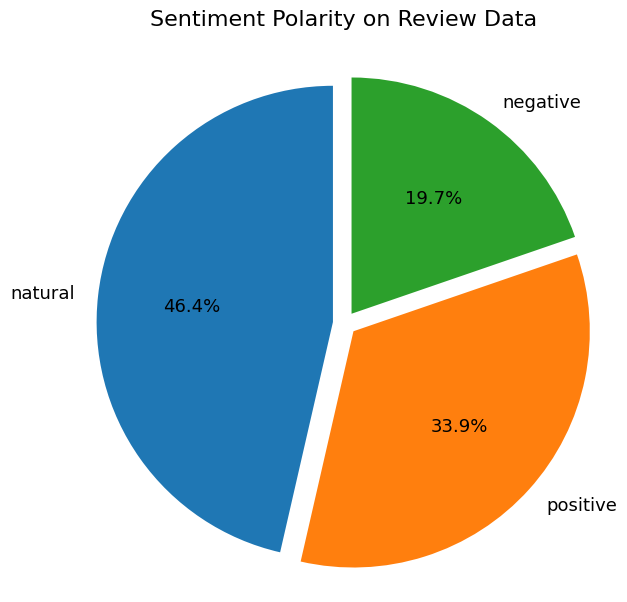

In [21]:
# Ambil jumlah data per kelas
sizes = new_df['lexicon_polarity'].value_counts().values
labels = new_df['lexicon_polarity'].value_counts().index.tolist()

# Meledakkan sedikit semua bagian supaya seimbang tampilannya (opsional)
explode = [0.05] * len(labels)

# Plot pie chart
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    x=sizes,
    labels=labels,
    autopct='%1.1f%%',
    explode=explode,
    textprops={'fontsize': 13},
    startangle=90
)
ax.set_title('Sentiment Polarity on Review Data', fontsize=16, pad=20)
ax.axis('equal')  # Agar pie chart berbentuk lingkaran sempurna
plt.show()

In [22]:
# ====== Positive Tweets ======
positive_tweets = (
    new_df[new_df['lexicon_polarity'] == 'positive']
    [['text_akhir', 'lexicon_score', 'lexicon_polarity', 'text_stopword']]
    .sort_values(by='lexicon_score', ascending=False)
    .reset_index(drop=True)
)
positive_tweets.index += 1

# ====== Negative Tweets ======
negative_tweets = (
    new_df[new_df['lexicon_polarity'] == 'negative']
    [['text_akhir', 'lexicon_score', 'lexicon_polarity', 'text_stopword']]
    .sort_values(by='lexicon_score', ascending=True)
    .head(10)
    .reset_index(drop=True)
)
negative_tweets.index += 1

# ====== Neutral Tweets (opsional) ======
neutral_tweets = (
    new_df[new_df['lexicon_polarity'] == 'neutral']
    [['text_akhir', 'lexicon_score', 'lexicon_polarity', 'text_stopword']]
    .sort_values(by='lexicon_score', ascending=True)
    .head(10)
    .reset_index(drop=True)
)
neutral_tweets.index += 1

# Menampilkan hasil
print("Positive Tweets:")
print(positive_tweets.head())

print("\nNegative Tweets:")
print(negative_tweets.head())

print("\nNatural Tweets:")
print(neutral_tweets.head())

Positive Tweets:
                                          text_akhir  lexicon_score  \
1  perkenalkan nama ayu tu bagus banget biar anak...             34   
2  webtoon udh top alfa mart mudah gk top webtoon...             30   
3  bagus baca novel baca novel suka kayak pop mar...             30   
4  mantap lanjutkan tower good baca tower good ta...             30   
5  tiba² rating dewasa komik baca padhal umur pen...             30   

  lexicon_polarity                                      text_stopword  
1         positive  [perkenalkan, nama, ayu, tu, bagus, banget, bi...  
2         positive  [webtoon, udh, top, alfa, mart, mudah, gk, top...  
3         positive  [bagus, baca, novel, baca, novel, suka, kayak,...  
4         positive  [mantap, lanjutkan, tower, good, baca, tower, ...  
5         positive  [tiba², rating, dewasa, komik, baca, padhal, u...  

Negative Tweets:
                                          text_akhir  lexicon_score  \
1  bnget kasar cmn gara jaringan an

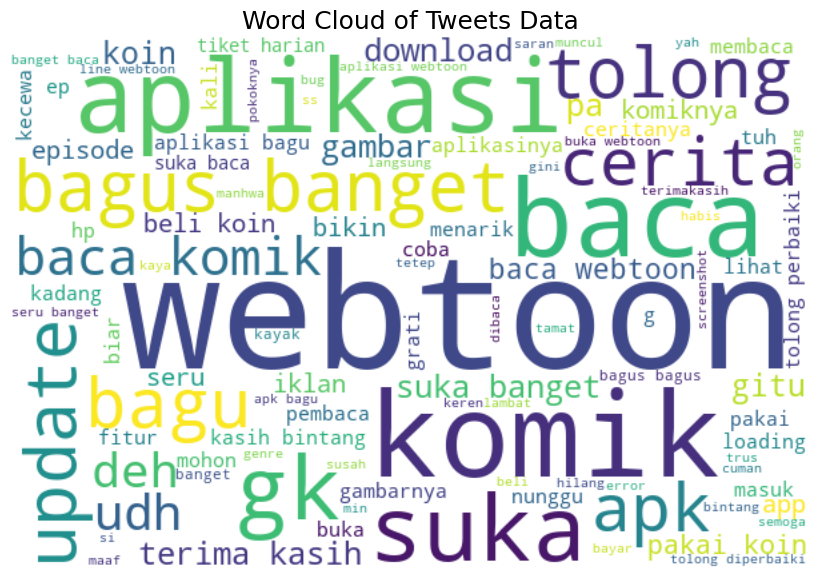

In [23]:
# Jumlah baris yang ingin digunakan untuk WordCloud
n_rows = 10000

# Cek agar tidak melebihi jumlah data yang tersedia
n_rows = min(n_rows, len(clean_df))

# Gabungkan kata dari tweet yang sudah dihapus stopword-nya
list_words = ' '.join([' '.join(tweet) for tweet in clean_df['text_stopword'][:n_rows]])

# Buat objek WordCloud
wordcloud = WordCloud(
    width=600,
    height=400,
    background_color='white',
    min_font_size=10,
    max_words=200  # batas maksimal kata yang divisualisasikan
).generate(list_words)

# Visualisasi WordCloud
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Tweets Data', fontsize=18)
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.grid(False)
plt.tight_layout(pad=0)
plt.show()

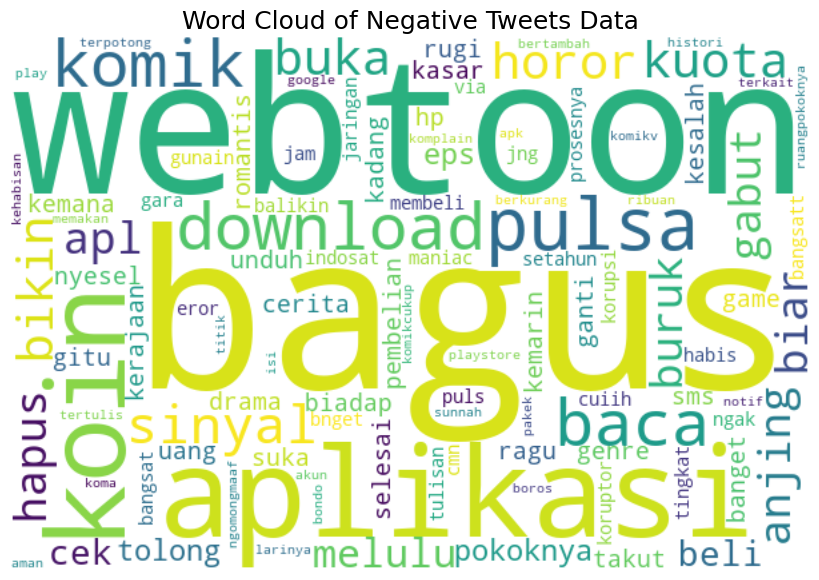

In [24]:
# Gabungkan kata dari tweet negatif yang sudah dihapus stopword-nya
list_words = ' '.join([' '.join(tweet) for tweet in negative_tweets['text_stopword']])

# Buat objek WordCloud
wordcloud = WordCloud(
    width=600,
    height=400,
    background_color='white',
    min_font_size=10,
    max_words=200  # batasi jumlah kata yang divisualisasikan
).generate(list_words)

# Visualisasi WordCloud
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Negative Tweets Data', fontsize=18)
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.grid(False)
plt.tight_layout(pad=0)
plt.show()

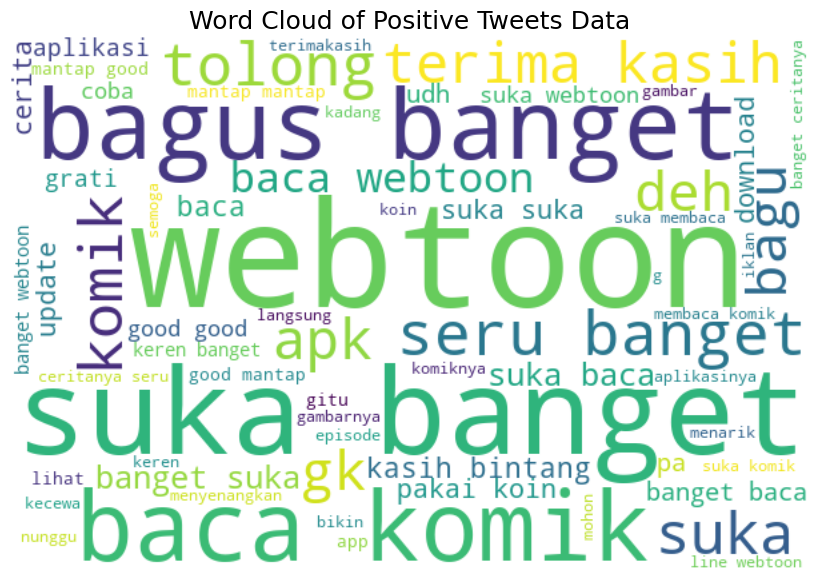

In [25]:
# Gabungkan kata dari tweet positif
list_words = ' '.join([' '.join(tweet) for tweet in positive_tweets['text_stopword']])

# Buat WordCloud
wordcloud = WordCloud(
    width=600,
    height=400,
    background_color='white',
    min_font_size=10,
    max_words=200
).generate(list_words)

# Visualisasi WordCloud
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Positive Tweets Data', fontsize=18)
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.grid(False)
plt.tight_layout(pad=0)
plt.show()

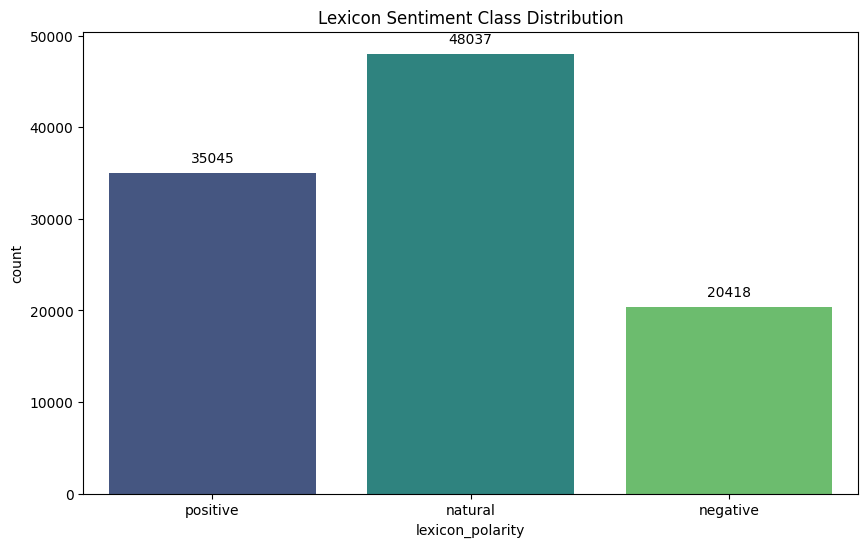

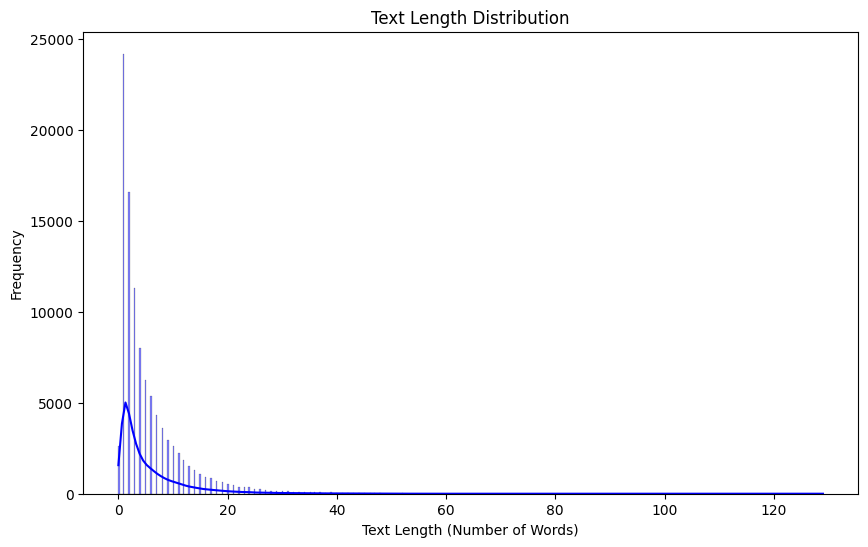

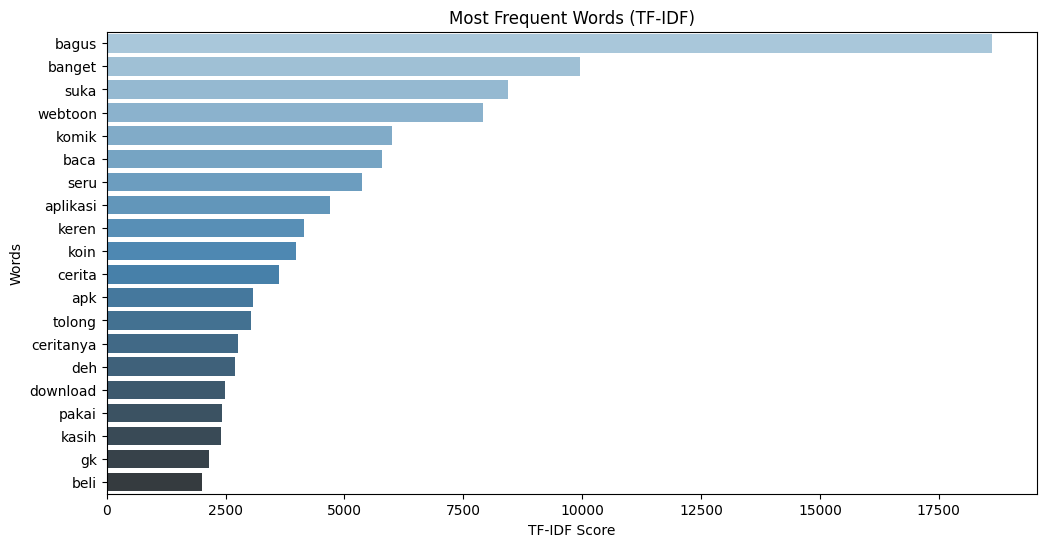

In [26]:
# ====== Class Distribution ======
plt.figure(figsize=(10, 6))

# Visualize the class distribution of 'polarity' (positive, negative, neutral)
class_dist_plot = sns.countplot(x='lexicon_polarity', data=new_df, hue='lexicon_polarity', palette='viridis', legend=False)
plt.title('Lexicon Sentiment Class Distribution')

# Add counts above the bars on the plot
for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='center',
                              xytext=(0, 10),
                              textcoords='offset points')

plt.show()

# ====== Text Length Distribution ======
plt.figure(figsize=(10, 6))

# Visualize text length distribution
new_df['text_length'] = new_df['text_akhir'].apply(lambda x: len(x.split()))  # Hitung jumlah kata
sns.histplot(new_df['text_length'], kde=True, color='blue')  # Adding KDE for a smoother distribution
plt.title('Text Length Distribution')
plt.xlabel('Text Length (Number of Words)')
plt.ylabel('Frequency')
plt.show()

# ====== Most Frequent Words (TF-IDF) ======
plt.figure(figsize=(12, 6))

# Visualize the most frequent words using TF-IDF
vectorizer = TfidfVectorizer(max_features=20)  # Top 20 kata
X = vectorizer.fit_transform(new_df['text_akhir'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False)

# Plot the top 20 frequent words using a bar plot
sns.barplot(x='jumlah', y='index', hue='index', data=tfidf_df, palette="Blues_d", legend=False)
plt.title('Most Frequent Words (TF-IDF)')
plt.xlabel('TF-IDF Score')
plt.ylabel('Words')
plt.show()

## **Data Splitting**

In [27]:
new_df.head(2)

,reviewId,userName,userImage,content,score,thumbsUpCount,at,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,lexicon_score,lexicon_polarity,text_length
0,beabc610-0bc7-4046-bc00-d83c3d86c2db,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya menggunakan aplikasi ini sudah lama. Vitu...,5,550,2025-03-29 18:32:43,3.6.2,saya menggunakan aplikasi ini sudah lama Vitur...,saya menggunakan aplikasi ini sudah lama vitur...,saya menggunakan aplikasi ini sudah lama vitur...,"[saya, menggunakan, aplikasi, ini, sudah, lama...","[aplikasi, vitur², aplikasi, oke, gambargambar...",aplikasi vitur² aplikasi oke gambargambarnya b...,4,positive,24
1,fb236561-5da0-4efa-9407-e52487abf420,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,hari sebelum nya masih bisa baca yg blm di bac...,3,5,2025-04-14 21:33:20,3.6.4,hari sebelum nya masih bisa baca yg blm di bac...,hari sebelum nya masih bisa baca yg blm di bac...,hari sebelum nya masih bisa baca yang belum di...,"[hari, sebelum, nya, masih, bisa, baca, yang, ...","[baca, baca, tibatiba, list, baca, hilang, sih...",baca baca tibatiba list baca hilang sihh susah...,0,natural,30


In [28]:
# Misalnya, 'polarity' adalah kolom label (target) dan 'text_akhir' adalah kolom fitur (text)
X = new_df['text_akhir']
y = new_df['lexicon_polarity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Split data
X = new_df['text_akhir']
y = new_df['lexicon_polarity']

# Split data: 80% untuk latih, 20% untuk uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tokenisasi
tokenizer = Tokenizer(num_words=5000)  # hanya menggunakan 5000 kata paling sering
tokenizer.fit_on_texts(X_train)

# Mengubah teks menjadi urutan angka (sequence)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding agar semua input teks memiliki panjang yang sama
max_len = 100  # Misalnya, panjang maksimal 100 kata
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# Menyandikan target label (sentimen) menjadi angka
y_train = y_train.map({'positive': 2, 'natural': 1, 'negative': 0})
y_test = y_test.map({'positive': 2, 'natural': 1, 'negative': 0})


In [30]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout

# Membangun model LSTM
model = Sequential()

# Layer Embedding untuk representasi kata
model.add(Embedding(input_dim=5000, output_dim=128, input_length=max_len))

# LSTM layer
model.add(LSTM(128, return_sequences=False))  # 128 unit LSTM

# Dropout untuk regularisasi
model.add(Dropout(0.5))

# Output layer (3 kelas: positive, neutral, negative)
model.add(Dense(3, activation='softmax'))  # Softmax untuk klasifikasi multi-kelas

# Kompilasi model
model.compile(loss='sparse_categorical_crossentropy', 
              optimizer='adam', 
              metrics=['accuracy'])


D:\muza\MINICOURSE\DICODING\Laskar AI 2025\submission3_1\env\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [31]:
# Melatih model
history = model.fit(X_train_pad, y_train, epochs=5, batch_size=64, validation_data=(X_test_pad, y_test))

# Evaluasi model
loss, accuracy = model.evaluate(X_test_pad, y_test)
print(f'Accuracy: {accuracy * 100:.2f}%')


Epoch 1/5
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 136s 99ms/step - accuracy: 0.7914 - loss: 0.4838 - val_accuracy: 0.9414 - val_loss: 0.1664
Epoch 2/5
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 189s 146ms/step - accuracy: 0.9537 - loss: 0.1367 - val_accuracy: 0.9585 - val_loss: 0.1321
Epoch 3/5
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 160s 124ms/step - accuracy: 0.9703 - loss: 0.0962 - val_accuracy: 0.9612 - val_loss: 0.1231
Epoch 4/5
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 154s 119ms/step - accuracy: 0.9771 - loss: 0.0791 - val_accuracy: 0.9649 - val_loss: 0.1284
Epoch 5/5
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 156s 121ms/step - accuracy: 0.9817 - loss: 0.0673 - val_accuracy: 0.9639 - val_loss: 0.1316
647/647 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.9646 - loss: 0.1319
Accuracy: 96.39%


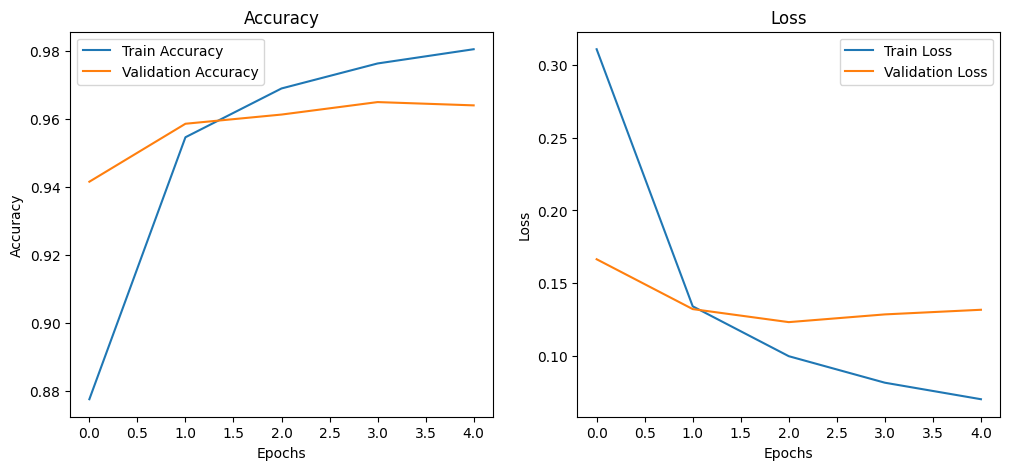

In [32]:
import matplotlib.pyplot as plt

# Plot akurasi dan loss selama pelatihan
plt.figure(figsize=(12, 5))

# Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [33]:
y_pred = model.predict(X_test_pad)
y_pred = y_pred.argmax(axis=1)  # Ambil kelas dengan probabilitas tertinggi

from sklearn.metrics import classification_report

# Menampilkan classification report
print(classification_report(y_test, y_pred, target_names=['negative', 'natural', 'positive']))

647/647 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step
              precision    recall  f1-score   support

    negative       0.95      0.94      0.95      3974
     natural       0.97      0.96      0.96      9653
    positive       0.97      0.98      0.97      7073

    accuracy                           0.96     20700
   macro avg       0.96      0.96      0.96     20700
weighted avg       0.96      0.96      0.96     20700



In [34]:
# Membuat objek TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)  # Mengambil hanya 5000 fitur teratas

# Melakukan fit-transform pada data latih
X_train_tfidf = vectorizer.fit_transform(X_train)

# Melakukan transform pada data uji
X_test_tfidf = vectorizer.transform(X_test)

# LSTM

In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Prediksi LSTM untuk data training
y_train_pred = model.predict(X_train_pad)
y_train_pred = y_train_pred.argmax(axis=1)

# Prediksi LSTM untuk data testing
y_test_pred = model.predict(X_test_pad)
y_test_pred = y_test_pred.argmax(axis=1)

# Evaluasi Train
train_accuracy = accuracy_score(y_train, y_train_pred)

# Evaluasi Test
test_accuracy = accuracy_score(y_test, y_test_pred)
precision_lstm = precision_score(y_test, y_test_pred, average='weighted')
recall_lstm = recall_score(y_test, y_test_pred, average='weighted')
f1_lstm = f1_score(y_test, y_test_pred, average='weighted')

print("=== LSTM Evaluation ===")
print("Train Accuracy:", train_accuracy)
print("Test Accuracy :", test_accuracy)
print("Precision     :", precision_lstm)
print("Recall        :", recall_lstm)
print("F1 Score      :", f1_lstm)
print()
print(classification_report(y_test, y_test_pred, target_names=['negative', 'natural', 'positive']))

2588/2588 ━━━━━━━━━━━━━━━━━━━━ 105s 41ms/step
647/647 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step
=== LSTM Evaluation ===
Train Accuracy: 0.9890579710144928
Test Accuracy : 0.9639130434782609
Precision     : 0.9638751361043679
Recall        : 0.9639130434782609
F1 Score      : 0.963877476885933

              precision    recall  f1-score   support

    negative       0.95      0.94      0.95      3974
     natural       0.97      0.96      0.96      9653
    positive       0.97      0.98      0.97      7073

    accuracy                           0.96     20700
   macro avg       0.96      0.96      0.96     20700
weighted avg       0.96      0.96      0.96     20700



## **Logistic Regression**

In [49]:
# Inisialisasi dan latih model Logistic Regression
logistic_regression = LogisticRegression(max_iter=1000)  # Menambahkan max_iter untuk memastikan konvergensi
logistic_regression.fit(X_train_tfidf, y_train)

# Prediksi pada data uji
y_pred_log_reg_test = logistic_regression.predict(X_test_tfidf)

# Prediksi pada data latih
y_pred_log_reg_train = logistic_regression.predict(X_train_tfidf)

# Evaluasi model pada data latih
print("Logistic Regression Train Accuracy: ", accuracy_score(y_train, y_pred_log_reg_train))
print("Classification Report on Train Data:\n", classification_report(y_train, y_pred_log_reg_train, target_names=['negative', 'natural', 'positive']))

# Evaluasi model pada data uji
print("Logistic Regression Test Accuracy: ", accuracy_score(y_test, y_pred_log_reg_test))
print("Classification Report on Test Data:\n", classification_report(y_test, y_pred_log_reg_test, target_names=['negative', 'natural', 'positive']))

Logistic Regression Train Accuracy:  0.9133816425120773
Classification Report on Train Data:
               precision    recall  f1-score   support

    negative       0.89      0.84      0.86     16444
     natural       0.90      0.92      0.91     38384
    positive       0.94      0.94      0.94     27972

    accuracy                           0.91     82800
   macro avg       0.91      0.90      0.91     82800
weighted avg       0.91      0.91      0.91     82800

Logistic Regression Test Accuracy:  0.8888888888888888
Classification Report on Test Data:
               precision    recall  f1-score   support

    negative       0.85      0.79      0.82      3974
     natural       0.88      0.90      0.89      9653
    positive       0.93      0.93      0.93      7073

    accuracy                           0.89     20700
   macro avg       0.88      0.87      0.88     20700
weighted avg       0.89      0.89      0.89     20700



## **Random Forest** 

In [37]:
# Inisialisasi dan latih model Random Forest
random_forest = RandomForestClassifier(random_state=42)  # Menambahkan random_state untuk memastikan hasil yang konsisten
random_forest.fit(X_train_tfidf, y_train)

# Prediksi pada data uji
y_pred_rf_test = random_forest.predict(X_test_tfidf)

# Prediksi pada data latih
y_pred_rf_train = random_forest.predict(X_train_tfidf)

# Evaluasi model pada data latih
print("Random Forest Train Accuracy: ", accuracy_score(y_train, y_pred_rf_train))
print("Classification Report on Train Data (Random Forest):\n", classification_report(y_train, y_pred_rf_train, target_names=['negative', 'natural', 'positive']))

# Evaluasi model pada data uji
print("Random Forest Test Accuracy: ", accuracy_score(y_test, y_pred_rf_test))
print("Classification Report on Test Data (Random Forest):\n", classification_report(y_test, y_pred_rf_test, target_names=['negative', 'natural', 'positive']))

Random Forest Train Accuracy:  0.9979830917874396
Classification Report on Train Data (Random Forest):
               precision    recall  f1-score   support

    negative       1.00      0.99      1.00     16444
     natural       1.00      1.00      1.00     38384
    positive       1.00      1.00      1.00     27972

    accuracy                           1.00     82800
   macro avg       1.00      1.00      1.00     82800
weighted avg       1.00      1.00      1.00     82800

Random Forest Test Accuracy:  0.8729468599033816
Classification Report on Test Data (Random Forest):
               precision    recall  f1-score   support

    negative       0.82      0.79      0.81      3974
     natural       0.91      0.87      0.89      9653
    positive       0.86      0.93      0.89      7073

    accuracy                           0.87     20700
   macro avg       0.86      0.86      0.86     20700
weighted avg       0.87      0.87      0.87     20700



## **Support Vector Machines (SVM)** 

## **Decision Tree**

In [38]:
# Inisialisasi dan latih model SVM
svm = SVC(kernel='linear', random_state=42)  # Kamu bisa menggunakan kernel lain jika perlu
svm.fit(X_train_tfidf, y_train)

# Prediksi pada data uji
y_pred_svm = svm.predict(X_test_tfidf)
y_pred_train_svm = svm.predict(X_train_tfidf)

# Evaluasi model pada data uji (test set)
print("SVM Accuracy on Test Set: ", accuracy_score(y_test, y_pred_svm))
print("Classification Report on Test Data (SVM):\n", classification_report(y_test, y_pred_svm, target_names=['negative', 'natural', 'positive']))

# Evaluasi model pada data pelatihan (train set)
print("SVM Accuracy on Train Set: ", accuracy_score(y_train, y_pred_train_svm))
print("Classification Report on Train Data (SVM):\n", classification_report(y_train, y_pred_train_svm, target_names=['negative', 'natural', 'positive']))

SVM Accuracy on Test Set:  0.9162318840579711
Classification Report on Test Data (SVM):
               precision    recall  f1-score   support

    negative       0.88      0.82      0.85      3974
     natural       0.90      0.92      0.91      9653
    positive       0.95      0.96      0.95      7073

    accuracy                           0.92     20700
   macro avg       0.91      0.90      0.91     20700
weighted avg       0.92      0.92      0.92     20700

SVM Accuracy on Train Set:  0.9377053140096618
Classification Report on Train Data (SVM):
               precision    recall  f1-score   support

    negative       0.92      0.87      0.89     16444
     natural       0.93      0.95      0.94     38384
    positive       0.96      0.97      0.96     27972

    accuracy                           0.94     82800
   macro avg       0.94      0.93      0.93     82800
weighted avg       0.94      0.94      0.94     82800



In [48]:
# Inisialisasi dan latih model Decision Tree
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train_tfidf, y_train)

# Prediksi pada data uji
y_pred_dt_test = decision_tree.predict(X_test_tfidf)

# Prediksi pada data latih
y_pred_dt_train = decision_tree.predict(X_train_tfidf)

# Evaluasi model pada data latih
print("Decision Tree Train Accuracy: ", accuracy_score(y_train, y_pred_dt_train))
print("Classification Report on Train Data:\n", classification_report(y_train, y_pred_dt_train, target_names=['negative', 'natural', 'positive']))

# Evaluasi model pada data uji
print("Decision Tree Test Accuracy: ", accuracy_score(y_test, y_pred_dt_test))
print("Classification Report on Test Data:\n", classification_report(y_test, y_pred_dt_test, target_names=['negative', 'natural', 'positive']))

Decision Tree Train Accuracy:  0.9979830917874396
Classification Report on Train Data:
               precision    recall  f1-score   support

    negative       1.00      0.99      1.00     16444
     natural       1.00      1.00      1.00     38384
    positive       1.00      1.00      1.00     27972

    accuracy                           1.00     82800
   macro avg       1.00      1.00      1.00     82800
weighted avg       1.00      1.00      1.00     82800

Decision Tree Test Accuracy:  0.8328985507246377
Classification Report on Test Data:
               precision    recall  f1-score   support

    negative       0.73      0.70      0.72      3974
     natural       0.87      0.87      0.87      9653
    positive       0.84      0.86      0.85      7073

    accuracy                           0.83     20700
   macro avg       0.81      0.81      0.81     20700
weighted avg       0.83      0.83      0.83     20700



In [44]:
# Buat list untuk menyimpan hasil
results = []

# LSTM (Asumsi prediksi LSTM ada pada y_pred_lstm_train dan y_pred_lstm_test)
results.append({
    "Model": "LSTM",
    "Train Accuracy": accuracy_score(y_train, y_train_pred),
    "Test Accuracy": accuracy_score(y_test, y_test_pred)
})

# Logistic Regression
results.append({
    "Model": "Logistic Regression",
    "Train Accuracy": accuracy_score(y_train, y_pred_log_reg_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_log_reg_test)
})

# Random Forest
results.append({
    "Model": "Random Forest",
    "Train Accuracy": accuracy_score(y_train, y_pred_rf_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_rf_test)
})

# Decision Tree
results.append({
    "Model": "Decision Tree",
    "Train Accuracy": accuracy_score(y_train, y_pred_dt_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_dt_test)
})

# Tampilkan dalam DataFrame
results_df = pd.DataFrame(results)

# Tampilkan hanya Accuracy Test
accuracy_test_only = results_df[['Model', 'Test Accuracy']]

# Mengurutkan DataFrame berdasarkan akurasi pengujian dari tertinggi ke terendah
accuracy_test_sorted = accuracy_test_only.sort_values(by='Test Accuracy', ascending=False)

print("\n==== Full Accuracy Results ====")
print(results_df)

# Output
print("\n==== Accuracy Test Only ====")
print(accuracy_test_only)

# Menampilkan hasil urutan akurasi model pada data uji
print("\n=== Model berdasarkan Test Accuracy (Tertinggi ke Terendah) ===")
print(accuracy_test_sorted)


==== Full Accuracy Results ====
                 Model  Train Accuracy  Test Accuracy
0                 LSTM        0.989058       0.963913
1  Logistic Regression        0.913382       0.888889
2        Random Forest        0.997983       0.872947
3        Decision Tree        0.997983       0.832899

==== Accuracy Test Only ====
                 Model  Test Accuracy
0                 LSTM       0.963913
1  Logistic Regression       0.888889
2        Random Forest       0.872947
3        Decision Tree       0.832899

=== Model berdasarkan Test Accuracy (Tertinggi ke Terendah) ===
                 Model  Test Accuracy
0                 LSTM       0.963913
1  Logistic Regression       0.888889
2        Random Forest       0.872947
3        Decision Tree       0.832899
